In [2]:
import sys
from pathlib import Path

# Let the notebook import our own code from src/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from src.training.train import load_split, make_model, MODELS_DIR
from src.training.preprocess import NUMERIC_FEATURES
from src.training.evaluate import evaluate

X_train, y_train = load_split("train")
X_val, y_val = load_split("val")
xgb = joblib.load(MODELS_DIR / "xgboost.joblib")
print("Loaded:", X_train.shape, X_val.shape)

Loaded: (924850, 15) (371825, 15)


In [3]:
scores = xgb.predict_proba(X_val)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_val, scores >= 0.5).ravel()

print(f"Frauds caught (TP):       {tp:>8,}")
print(f"Frauds missed (FN):       {fn:>8,}")
print(f"False alarms (FP):        {fp:>8,}  -> {fp / (fp + tn):.3%} of legit customers")
print(f"Correctly approved (TN):  {tn:>8,}")

Frauds caught (TP):          2,225
Frauds missed (FN):             61
False alarms (FP):             480  -> 0.130% of legit customers
Correctly approved (TN):   369,059


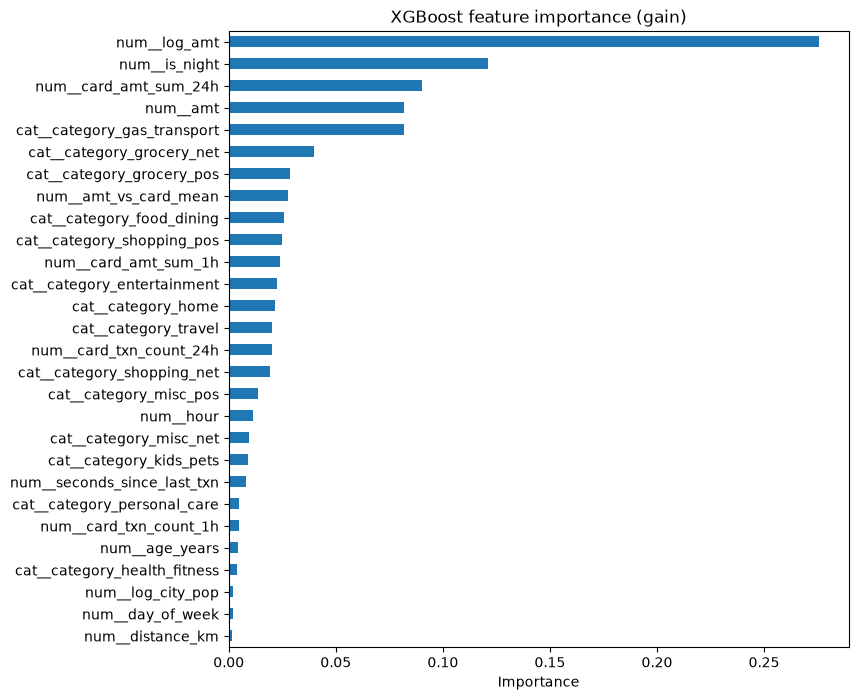

In [4]:
names = xgb["preprocess"].get_feature_names_out()
importance = pd.Series(xgb["model"].feature_importances_, index=names).sort_values()

ax = importance.plot(kind="barh", figsize=(8, 8))
ax.set_title("XGBoost feature importance (gain)")
ax.set_xlabel("Importance")
plt.show()

In [5]:
CARD_HISTORY = [f for f in NUMERIC_FEATURES if f.startswith(("card_", "seconds_", "amt_vs"))]
AMOUNT = ["amt", "log_amt", "card_amt_sum_1h", "card_amt_sum_24h", "amt_vs_card_mean"]

experiments = {
    "all features": NUMERIC_FEATURES,
    "no card history": [f for f in NUMERIC_FEATURES if f not in CARD_HISTORY],
    "no amount features": [f for f in NUMERIC_FEATURES if f not in AMOUNT],
}

rows = {}
for name, numeric in experiments.items():
    print("Training:", name)
    model = make_model("xgboost", y_train, numeric=numeric).fit(X_train, y_train)
    m = evaluate(y_val, model.predict_proba(X_val)[:, 1])
    rows[name] = {k: m[k] for k in ["pr_auc", "recall_at_1pct_fpr", "precision", "recall"]}

ablation = pd.DataFrame(rows).T.round(4)
ablation

Training: all features
Training: no card history
Training: no amount features


,pr_auc,recall_at_1pct_fpr,precision,recall
all features,0.9835,0.9961,0.8226,0.9733
no card history,0.8947,0.9580,0.4442,0.9440
no amount features,0.3987,0.4742,0.0835,0.7060


## Findings

**Baseline comparison (validation set):** XGBoost PR-AUC 0.9835 vs logistic regression 0.4315
vs dummy 0.0061 (= base rate). Logistic regression reaches ROC-AUC 0.99 but only 14% precision,
confirming that ROC-AUC is misleading under heavy class imbalance.

**Error profile at threshold 0.5:** 2,225 frauds caught, 61 missed (recall 97.3%);
480 false alarms, i.e. 0.13% of legitimate customers.

**Feature importance** matches the EDA: `log_amt`, `is_night`, `card_amt_sum_24h`, `amt`
and merchant category dominate. `amt` and `log_amt` carry the same information, so their
importance is split between them.

**Ablation study:**

| Experiment | PR-AUC | Precision | Recall |
|---|---|---|---|
| All features | 0.9835 | 0.82 | 0.97 |
| No card-history features | 0.8947 | 0.44 | 0.94 |
| No amount features | 0.3987 | 0.08 | 0.71 |

- Removing real-time card-history features roughly halves precision: about **5.6x more false
  alarms** (~2,700 vs 480) at similar recall. **This justifies the streaming architecture.**
- Amount features are the strongest signal. The two groups overlap slightly
  (`card_amt_sum_*`, `amt_vs_card_mean` belong to both).

**Credibility:** no sign of leakage (leakage unit test passes, model relies on EDA-consistent
signals, ablations degrade as expected). However, fraud patterns in this simulated dataset are
unusually clean, so these scores are likely **optimistic** compared with real bank data.

In [6]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import time

strategies = {
    "no handling": dict(class_weighting=False),
    "class weights": dict(class_weighting=True),
    "undersampling": dict(
        class_weighting=False,
        samplers=[RandomUnderSampler(sampling_strategy=0.1, random_state=42)],
    ),
    "SMOTE": dict(
        class_weighting=False,
        samplers=[SMOTE(sampling_strategy=0.1, random_state=42)],
    ),
    "undersampling + SMOTE-Tomek": dict(
        class_weighting=False,
        samplers=[
            RandomUnderSampler(sampling_strategy=0.1, random_state=42),
            SMOTETomek(sampling_strategy=0.3, random_state=42),
        ],
    ),
}

rows = {}
for name, options in strategies.items():
    print("Training:", name)
    start = time.perf_counter()
    model = make_model("xgboost", y_train, **options).fit(X_train, y_train)
    m = evaluate(y_val, model.predict_proba(X_val)[:, 1])
    rows[name] = {k: m[k] for k in ["pr_auc", "recall_at_1pct_fpr", "precision", "recall"]}
    rows[name]["train_seconds"] = time.perf_counter() - start

imbalance = pd.DataFrame(rows).T.round(4)
imbalance

Training: no handling
Training: class weights
Training: undersampling
Training: SMOTE
Training: undersampling + SMOTE-Tomek


,pr_auc,recall_at_1pct_fpr,precision,recall,train_seconds
no handling,0.9814,0.9956,0.9631,0.9143,56.8765
class weights,0.9835,0.9961,0.8226,0.9733,49.8973
undersampling,0.9804,0.9943,0.7932,0.9733,7.7692
SMOTE,0.9853,0.9956,0.9573,0.9418,66.5803
undersampling + SMOTE-Tomek,0.9799,0.9952,0.7558,0.9764,31.9417


## Class-imbalance strategies

| Strategy | PR-AUC | Precision @0.5 | Recall @0.5 | Train time |
|---|---|---|---|---|
| No handling | 0.9814 | 0.96 | 0.91 | 60 s |
| Class weights | 0.9835 | 0.82 | 0.97 | 55 s |
| Random undersampling | 0.9804 | 0.79 | 0.97 | 7 s |
| SMOTE | 0.9853 | 0.96 | 0.94 | 61 s |
| Undersampling + SMOTE-Tomek | 0.9799 | 0.76 | 0.98 | 35 s |

- **Ranking quality is almost identical** (PR-AUC 0.980-0.985, recall @ 1% FPR 0.994-0.996).
  Differences are within single-run noise. Even "no handling" works: gradient boosting ranks
  rare frauds well on its own.
- Weighting and resampling mainly **shift the score distribution**, trading precision for recall
  at a fixed 0.5 threshold. **Choosing the decision threshold matters more than the resampling method.**
- SMOTE-Tomek on the full 925k rows was computationally impractical (nearest-neighbour search
  over every row), so it was applied after random undersampling.
- **Decision:** keep **class weights** (simple, no synthetic data, no data discarded).
  Random undersampling is ~8x faster at similar PR-AUC, a candidate for fast hyperparameter search.

Fraud losses with NO model:     $   1,220,266
Total cost at threshold 0.50:   $      16,412
Best threshold: 0.23  ->  cost $      13,752
At best threshold: precision=0.701, recall=0.986


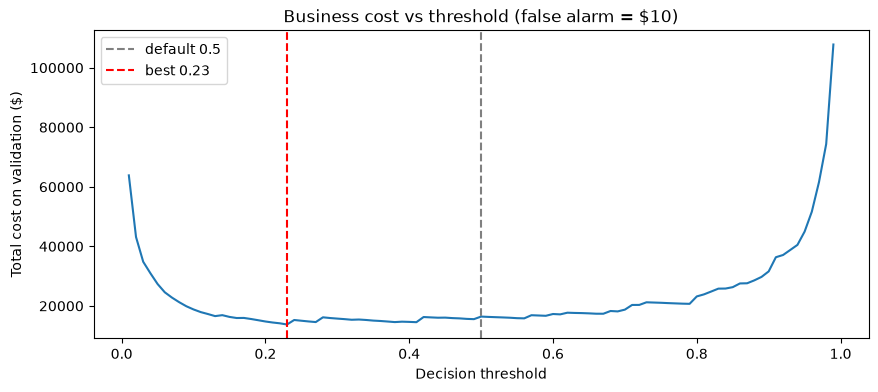

In [7]:
import numpy as np

scores = xgb.predict_proba(X_val)[:, 1]
y = y_val.to_numpy()
amounts = X_val["amt"].to_numpy()


def total_cost(threshold: float, fp_cost: float) -> float:
    flagged = scores >= threshold
    missed_fraud_loss = amounts[(y == 1) & ~flagged].sum()     # FN: we lose the money
    false_alarm_cost = fp_cost * ((y == 0) & flagged).sum()    # FP: review + friction
    return missed_fraud_loss + false_alarm_cost


FP_COST = 10.0
thresholds = np.linspace(0.01, 0.99, 99)
costs = np.array([total_cost(t, FP_COST) for t in thresholds])
best = thresholds[costs.argmin()]

no_model_loss = amounts[y == 1].sum()
print(f"Fraud losses with NO model:     ${no_model_loss:>12,.0f}")
print(f"Total cost at threshold 0.50:   ${total_cost(0.5, FP_COST):>12,.0f}")
print(f"Best threshold: {best:.2f}  ->  cost ${costs.min():>12,.0f}")

m = evaluate(y_val, scores, threshold=best)
print(f"At best threshold: precision={m['precision']:.3f}, recall={m['recall']:.3f}")

ax = pd.Series(costs, index=thresholds).plot(figsize=(10, 4))
ax.axvline(0.5, color="grey", linestyle="--", label="default 0.5")
ax.axvline(best, color="red", linestyle="--", label=f"best {best:.2f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Total cost on validation ($)")
ax.set_title(f"Business cost vs threshold (false alarm = ${FP_COST:.0f})")
ax.legend()
plt.show()

In [8]:
sensitivity = {}
for fp_cost in [2, 5, 10, 25, 50]:
    c = np.array([total_cost(t, fp_cost) for t in thresholds])
    t_best = thresholds[c.argmin()]
    m = evaluate(y_val, scores, threshold=t_best)
    sensitivity[f"${fp_cost}"] = {
        "best_threshold": t_best,
        "total_cost_$": c.min(),
        "precision": m["precision"],
        "recall": m["recall"],
    }

pd.DataFrame(sensitivity).T.round(3)

,best_threshold,total_cost_$,precision,recall
$2,0.13,5143.86,0.613,0.990
$5,0.23,8942.23,0.701,0.986
$10,0.23,13752.23,0.701,0.986
$25,0.67,21942.06,0.879,0.969
$50,0.79,28812.54,0.915,0.959


## Business-cost threshold selection

Cost model: a missed fraud costs its **transaction amount**; a false alarm costs an
**assumed $10** (analyst review + customer friction). Threshold chosen on the validation set.

| Scenario | Total cost on validation (6 months) |
|---|---|
| No model | $1,220,266 |
| XGBoost, threshold 0.50 | $16,412 |
| XGBoost, **threshold 0.23** (cost-optimal) | **$13,752** |

- The model cuts fraud-related cost by **~98.9%**; moving the threshold from 0.50 to 0.23 saves
  a further ~16% (precision 0.70, recall 0.986).
- The cost curve has a **wide, flat minimum** (~0.15-0.6): the decision is robust to small
  threshold changes. Costs explode above ~0.9, where large frauds are missed.
- **Sensitivity:** as the false-alarm cost rises ($2 -> $50), the optimal threshold rises
  (0.13 -> 0.79), trading recall for precision. Because the minimum is flat, the optimum can jump.
- **Decision:** threshold **0.23** under the $10 assumption. It will be versioned with the model
  (MLflow) and used by the scoring API.

# Phase 2 summary

- Leakage-safe feature pipeline with 13 unit tests; chronological train / validation / test split.
- XGBoost PR-AUC 0.9835 vs logistic regression 0.4315 vs dummy 0.0061 (validation).
- Real-time card-history features cut false alarms ~5.6x: **the streaming architecture is justified**.
- Imbalance strategies give near-identical ranking quality; **threshold choice matters more**.
- Scores are likely optimistic: simulated data with unusually clean fraud patterns.
- The test set remains untouched for final evaluation.